# CVA / DVA / FVA — Introduction

## Why this matters

Post-2008, **counterparty credit risk** is no longer ignored. Every OTC derivatives trade carries **CVA** (Credit Valuation Adjustment) — the cost of the counterparty defaulting before the trade matures. Banks have entire **xVA desks** managing this.

You will be asked at any structurer/derivatives interview:
1. Define CVA, DVA, FVA. What's the relationship?
2. The **CVA formula** in expectation-form.
3. **Expected positive exposure (EPE)** — how to simulate.
4. **Wrong-way risk** — what is it?
5. CVA hedging — what's hedgeable, what's not?

This notebook covers the basics with a worked example on a swap.

## The xVA family

| Adjustment | Cost arising from | Sign for buyer |
|---|---|---|
| **CVA** (Credit) | Counterparty defaulting when MTM is positive (you owed money) | − (subtract from value) |
| **DVA** (Debit) | YOUR default when MTM is negative (you'd save) | + |
| **FVA** (Funding) | Cost of funding uncollateralised positions | − |
| **MVA** (Margin) | Cost of initial margin under SIMM | − |
| **KVA** (Capital) | Cost of regulatory capital | − |

**CVA formula** (expectation form, Brigo-Pallavicini-Rutkowski):

$$\text{CVA} = (1 - R) \int_0^T \mathbb{E}^Q\big[D(0, t) \cdot \max(V_t, 0) \cdot \lambda_t \big] \, dt$$

where:
- $R$ = recovery rate (typically 40%)
- $D(0, t)$ = discount factor
- $\max(V_t, 0)$ = positive exposure (you're owed)
- $\lambda_t$ = hazard rate (default intensity) of counterparty

In simplified form: CVA = (1 - R) × EPE × PD.

## Setup — simulate exposure on a swap

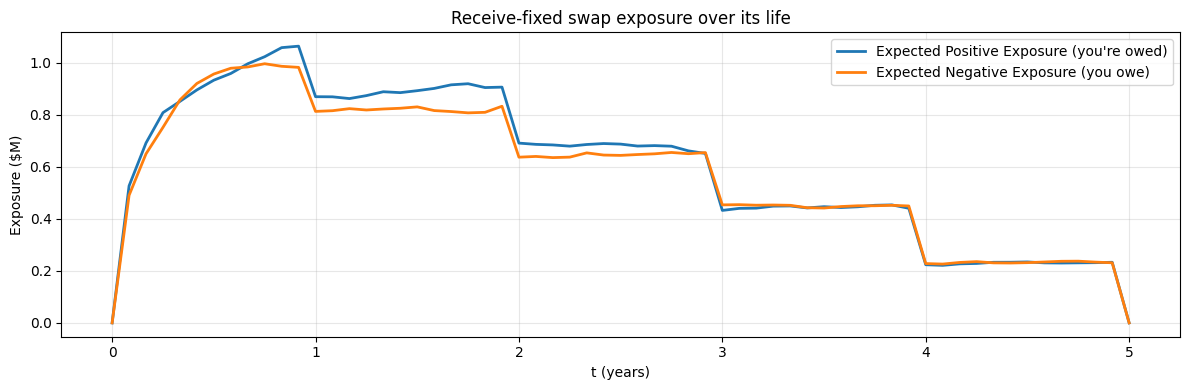


Max EPE: $1.06M (at t = 0.92y)


In [1]:
import warnings; warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 5y receive-fixed swap, $100M notional, 4% fixed coupon
T = 5.0
N = 1e8
K = 0.04
r0 = 0.04
sigma_r = 0.01   # vol of short rate

n_paths = 5000
n_steps = 60
dt = T / n_steps
rng = np.random.default_rng(42)

# Simulate short rate via Vasicek-like: dr = θ(μ - r) dt + σ dW
theta_v = 1.5
mu_v = 0.04
r_paths = np.full((n_paths, n_steps + 1), r0)
for t in range(n_steps):
    dW = rng.standard_normal(n_paths) * np.sqrt(dt)
    r_paths[:, t+1] = r_paths[:, t] + theta_v * (mu_v - r_paths[:, t]) * dt + sigma_r * dW

# At each future time t, MTM of swap = remaining cash flows discounted at the prevailing curve
# Simplification: assume flat-curve at r_t. MTM ≈ N · (K - r_t) · annuity(T - t)
def annuity_remaining(t, T_, r_):
    """Approximate annuity for [t, T] given flat rate r_."""
    if t >= T_: return 0
    n_pay = int(np.ceil(T_ - t))
    return sum(np.exp(-r_ * (k+1)) for k in range(n_pay))

# Compute MTM at each time step for each path
times = np.linspace(0, T, n_steps + 1)
mtm = np.zeros_like(r_paths)
for t_idx in range(n_steps + 1):
    t = times[t_idx]
    if t < T:
        mtm[:, t_idx] = N * (K - r_paths[:, t_idx]) * np.array([annuity_remaining(t, T, r) for r in r_paths[:, t_idx]])

# Expected Positive Exposure
epe_mc = np.mean(np.maximum(mtm, 0), axis=0)
ene_mc = np.mean(np.maximum(-mtm, 0), axis=0)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(times, epe_mc / 1e6, label='Expected Positive Exposure (you\'re owed)', lw=2)
ax.plot(times, ene_mc / 1e6, label='Expected Negative Exposure (you owe)', lw=2)
ax.set_xlabel('t (years)'); ax.set_ylabel('Exposure ($M)')
ax.set_title('Receive-fixed swap exposure over its life')
ax.legend(); ax.grid(alpha=0.3); plt.tight_layout(); plt.show()
print(f'\nMax EPE: ${epe_mc.max()/1e6:.2f}M (at t = {times[np.argmax(epe_mc)]:.2f}y)')

## Compute CVA

CVA on $100M 5y swap, hazard 2%, recovery 40%: $34,015
In bps of notional: 3.4 bps


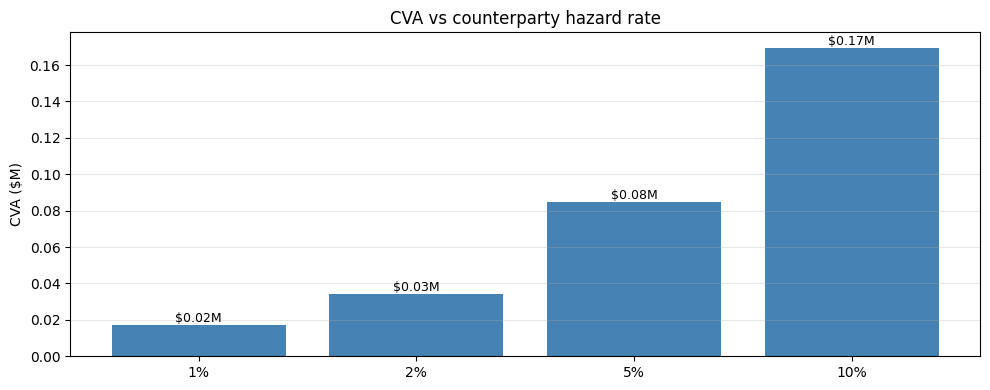

In [2]:
# CVA = (1 - R) × ∫ DF(t) × EPE(t) × hazard(t) dt
# Discrete: CVA = (1 - R) × Σ DF(t_i) × EPE(t_i) × PD_i

R = 0.40   # recovery
hazard = 0.02   # 2% / year — typical IG counterparty
spread_yrs = 0.04

# PD over each interval [t_{i-1}, t_i]: 1 - exp(-h × dt)
PDs = 1 - np.exp(-hazard * dt)

# Discount factors at each time step (using avg rate)
avg_r = r_paths.mean()
DFs = np.exp(-avg_r * times)

# CVA
CVA = (1 - R) * np.sum(DFs[1:] * epe_mc[1:] * PDs)
print(f'CVA on $100M 5y swap, hazard {hazard:.0%}, recovery {R:.0%}: ${CVA:,.0f}')
print(f'In bps of notional: {CVA / 1e8 * 1e4:.1f} bps')

# Sensitivity to hazard rate
fig, ax = plt.subplots(figsize=(10, 4))
for h in [0.01, 0.02, 0.05, 0.10]:
    cva_h = (1 - R) * np.sum(DFs[1:] * epe_mc[1:] * (1 - np.exp(-h * dt)))
    ax.bar(f'{h:.0%}', cva_h / 1e6, color='steelblue')
    ax.annotate(f'${cva_h/1e6:.2f}M', (f'{h:.0%}', cva_h/1e6), ha='center', va='bottom', fontsize=9)
ax.set_ylabel('CVA ($M)')
ax.set_title('CVA vs counterparty hazard rate')
ax.grid(alpha=0.3, axis='y'); plt.tight_layout(); plt.show()

## Wrong-way risk

**Wrong-way risk (WWR)** = correlation between the counterparty's default probability and your exposure to it. Bad combinations:

- Selling FX forward to a sovereign that *causes* its currency to weaken (FX exposure rises while sovereign more likely to default).
- Selling oil derivatives to an oil producer (low oil → both your exposure rises AND producer's PD rises).

**Right-way risk** is the opposite. CVA models add a correlation term between PD and exposure to capture WWR.

Modelling: copula-based (Brigo) or stochastic-intensity with correlated drivers (Lando).

## CVA hedging

What CAN be hedged:
- **Spread risk**: buy CDS on the counterparty.
- **Market exposure**: delta-hedge the underlying.

What CAN'T be (or is hard):
- **Jump-to-default risk**: discrete default event isn't continuously hedgeable.
- **Wrong-way risk**: hedging counterparty CDS is one thing, but hedging the correlation between exposure and PD is much harder.

Banks run dedicated **CVA desks** that aggregate across all counterparties, hedge spread risk via CDS, and reserve unhedgeable components.

## Exercises

### Exercise 1 — DVA mirror calculation

DVA is your own default risk on negative MTM. Compute DVA for the same swap using your own hazard rate of 1%.

In [3]:
# Your answer here


<details>
<summary><b>Reveal solution</b></summary>

```python
own_hazard = 0.01
PDs_own = 1 - np.exp(-own_hazard * dt)
DVA = (1 - R) * np.sum(DFs[1:] * ene_mc[1:] * PDs_own)
print(f'DVA: ${DVA:,.0f}')
print(f'CVA: ${CVA:,.0f}')
print(f'Net (CVA - DVA): ${CVA - DVA:,.0f}')
```

_DVA partially offsets CVA. Some banks net them; FVA is sometimes argued to reflect what's left over._

</details>

## Interview Q&A

**Q: Define CVA.**

A: Credit Valuation Adjustment. The expected loss from counterparty default before maturity, discounted to today. Approximately CVA = (1 - R) × EPE × PD.

**Q: Why did banks ignore CVA pre-2008?**

A: Counterparty default was viewed as remote — Lehman / AIG showed otherwise. Post-Basel III, banks required to charge CVA capital and report it.

**Q: CVA vs DVA vs FVA?**

A: CVA = counterparty's default risk (you lose). DVA = your default risk (you "save" by defaulting on what you owe). FVA = funding cost of uncollateralised positions. CVA is universal; DVA is controversial (you can't profit from defaulting on yourself); FVA debate is ongoing.

**Q: How do you compute EPE?**

A: Monte Carlo: simulate underlying paths under risk-neutral measure, MTM the trade at each future time, take expected positive exposure: $\text{EPE}(t) = \mathbb{E}^Q[\max(V_t, 0)]$.

**Q: What's wrong-way risk and how do you model it?**

A: Correlation between counterparty PD and your exposure. Models: copula between credit and market risk drivers, or stochastic-intensity with correlated diffusions. Hardest part of CVA to hedge.

## Pitfalls

| Pitfall | Issue | Fix |
|---|---|---|
| Wrong measure for CVA | EPE under Q (risk-neutral) for pricing | Always Q-measure for CVA |
| Ignoring DVA | Some firms include, others don't | Reconcile internal vs reported |
| Static recovery | R = 40% is convention; actual varies by sector | Use sector-specific recovery |
| Ignoring netting | Bilateral netting agreements reduce exposure | Aggregate at netting-set level |
| CVA on collateralised | Posted collateral reduces EPE | Correct EPE for collateral |
| Wrong-way risk | Standard formula assumes independence | Add correlation term explicitly |

## What you've earned

You can compute CVA on a swap via MC, distinguish CVA/DVA/FVA, simulate exposure profiles, explain wrong-way risk, and identify what's hedgeable. Foundation for any xVA-related interview.